# Churn Prediction for Shopping Extension

This notebook analyzes synthetic data modeling the first 90 days of user interaction with a browser shopping extension to predict user churn. The features are based on extension events like price comparison views, auto-apply coupons attempts, and cashback activations.

**Problem Description**: Predict whether a user will uninstall the extension (churn) based on their interaction metrics (successes, failures, savings, and earnings).

### 1. Data Loading
Let's load the data and look at a sample.

In [10]:
# Load the synthetic dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('shopping_extension_data.csv')
df.head()

,user_id,days_since_install,price_comp_views,coupon_attempts,coupon_successes,amount_saved,cashback_clicks,cashback_earned,total_interactions,churned
0,USR_000001,162,16,8,1,5.85,6,6.01,30,1
1,USR_000002,173,54,29,17,167.34,17,140.05,100,0
2,USR_000003,332,42,24,10,39.57,12,12.24,78,1
3,USR_000004,301,21,9,2,8.56,8,18.93,38,0
4,USR_000005,238,0,2,0,0.00,0,0.00,2,0


**What & Why we did this**: 
We loaded the dataset into a Pandas DataFrame and inspected the first few rows (`head()`). This is the foundational step in any data science problem. It helps verify that the dataset structure, column names, and data types match our expectations before we begin deep analysis.

**Interviewer Questions**:
- *"How would you handle reading this file if the dataset was 50GB and couldn't fit into memory using pandas?"* 
  - **Answer**: I would use `chunksize` in pandas to read the file in smaller batches, or transition to a distributed processing framework like Dask or PySpark.

### 2. Exploratory Data Analysis (EDA) and Feature Engineering

Let's create some derived features that might be strong predictors of churn, such as the *Coupon Success Rate*.

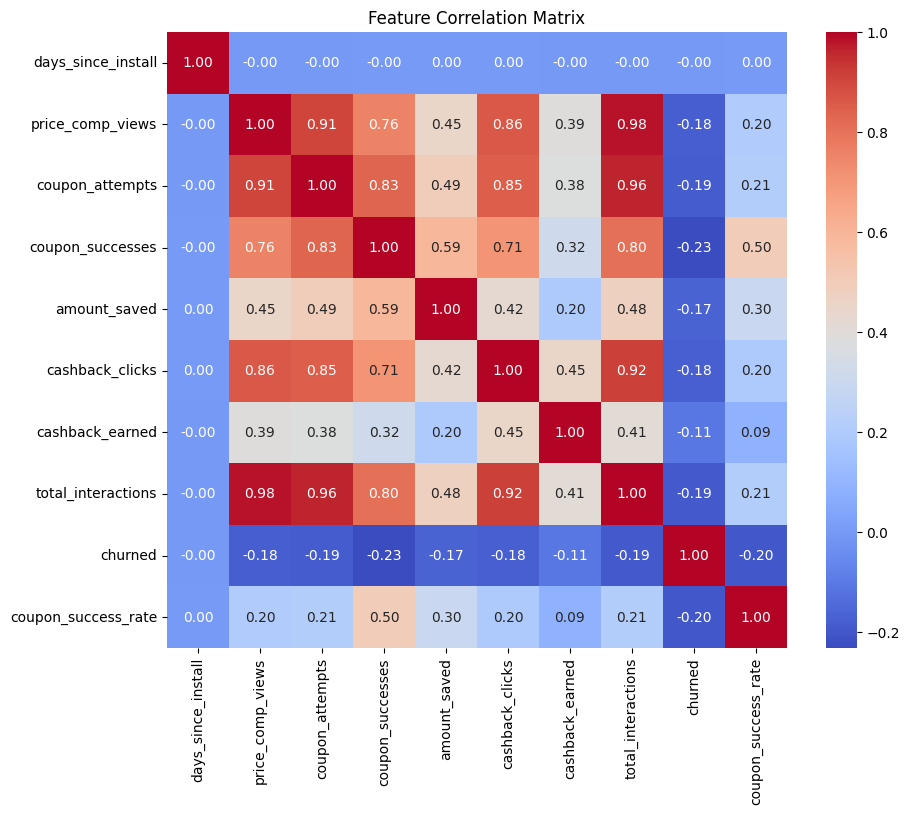

In [5]:
# Feature Engineering: Coupon Success Rate
# Handle division by zero for users with 0 attempts
df['coupon_success_rate'] = np.where(df['coupon_attempts'] > 0, 
                                     df['coupon_successes'] / df['coupon_attempts'], 
                                     0)

# Let's look at the correlation matrix to see what impacts Churn
plt.figure(figsize=(10, 8))
correlation_matrix = df.drop('user_id', axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

**What & Why we did this**: 
We engineered a new feature: `coupon_success_rate`. Raw metrics (like `coupon_attempts`) don't tell the full story. A user failing 9 out of 10 times signals high frustration, which directly impacts churn. Explicitly engineering this ratio provides a clearer, more direct signal to the model. We also plotted a correlation matrix to observe linear relationships and check for multicollinearity among inputs.

**Interviewer Questions**:
- *"Why engineer the success rate instead of just letting the model figure it out from attempts and successes?"* 
  - **Answer**: While advanced tree models can sometimes infer complex interactions, explicitly computing mathematical ratios offers a stronger, more direct signal. Linear models like Logistic Regression mathematically cannot infer division/ratios on their own.
- *"What is multicollinearity, and why is it a problem?"* 
  - **Answer**: Multicollinearity occurs when independent variables in a regression model are highly correlated. It makes it difficult to interpret the beta coefficients of the Logistic Regression model, leading to unstable feature importance estimates.

### 3. Machine Learning Modeling

We will split our data and build two models:
1. **Logistic Regression**: Great for baseline and interpretability (understanding *how* a feature impacts churn).
2. **Random Forest Classifier**: A tree-based ensemble method that can capture non-linear relationships and interactions between features.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Define Features (X) and Target (y)
features = ['price_comp_views', 'coupon_attempts', 'coupon_successes', 
            'amount_saved', 'cashback_clicks', 'cashback_earned', 
            'total_interactions', 'coupon_success_rate']

X = df[features]
y = df['churned']

# Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training instances: {len(X_train)}, Testing instances: {len(X_test)}")

Training instances: 80000, Testing instances: 20000


#### Model 1: Logistic Regression

In [7]:
# Initialize and train Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

# Predictions
lr_preds = lr_model.predict(X_test)
lr_probs = lr_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Evaluation:")
print(classification_report(y_test, lr_preds))
print(f"ROC-AUC Score: {roc_auc_score(y_test, lr_probs):.4f}")

Logistic Regression Evaluation:
              precision    recall  f1-score   support

           0       0.70      0.91      0.79     13174
           1       0.58      0.25      0.35      6826

    accuracy                           0.68     20000
   macro avg       0.64      0.58      0.57     20000
weighted avg       0.66      0.68      0.64     20000

ROC-AUC Score: 0.6712


**What & Why we did this**: 
We trained a Logistic Regression classifier as our baseline model. It operates by fitting a line to separate churners from non-churners based on continuous probabilities. We evaluated it using ROC-AUC instead of standard accuracy.

**Interviewer Questions**:
- *"Why start with Logistic Regression instead of jumping straight to XGBoost or Random Forest?"* 
  - **Answer**: Following Occam's razor—start simple. If a linear model performs sufficiently well, it's easier to maintain, deploy, and explain to non-technical stakeholders. It also establishes a baseline to determine if complex, heavy models offer enough 'lift' to justify their computational overhead.
- *"Why should we look at ROC-AUC or F1-Score instead of Accuracy?"* 
  - **Answer**: In imbalanced datasets, a model could simply predict "No Churn" 100% of the time. If the churn rate is 5%, the model is technically 95% accurate, but entirely useless. Precision, Recall, and ROC-AUC evaluate how well the model distinguishes between real classes.

#### Model 2: Random Forest

Random Forests generally perform exceptionally well on tabular behavioral data.

In [8]:
# Initialize and train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predictions
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest Evaluation:")
print(classification_report(y_test, rf_preds))
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_probs):.4f}")

Random Forest Evaluation:
              precision    recall  f1-score   support

           0       0.72      0.85      0.78     13174
           1       0.56      0.36      0.44      6826

    accuracy                           0.69     20000
   macro avg       0.64      0.61      0.61     20000
weighted avg       0.67      0.69      0.67     20000

ROC-AUC Score: 0.6555


**What & Why we did this**: 
We trained a Random Forest model, an ensemble model constructed of many decision trees (`n_estimators=100`). Unlike Logistic Regression, Random Forests can automatically capture deep, non-linear feature interactions (e.g., a high coupon failure rate might *only* cause churn if the total savings are also zero).

**Interviewer Questions**:
- *"How does a Random Forest mitigate overfitting compared to a single Decision Tree?"*
  - **Answer**: Through "Bagging" (Bootstrap Aggregating). It trains many trees on random sub-samples of the data, and randomly subsets the features available at each node split. This ensures the trees are uncorrelated. Averaging their predictions drastically reduces the model's overall variance and prevents overfitting.
- *"What are the primary hyperparameters you would tune for a Random Forest?"* 
  - **Answer**: The maximum depth of the trees (`max_depth`), the minimum number of samples required to split an internal node (`min_samples_split`), and the number of trees in the forest (`n_estimators`).

### 4. Optimized Solution & Feature Importance

To understand *why* users churn, we can look at the feature importance derived from the Random Forest model. This aligns strongly with optimized tree-based modeling for churn domains.

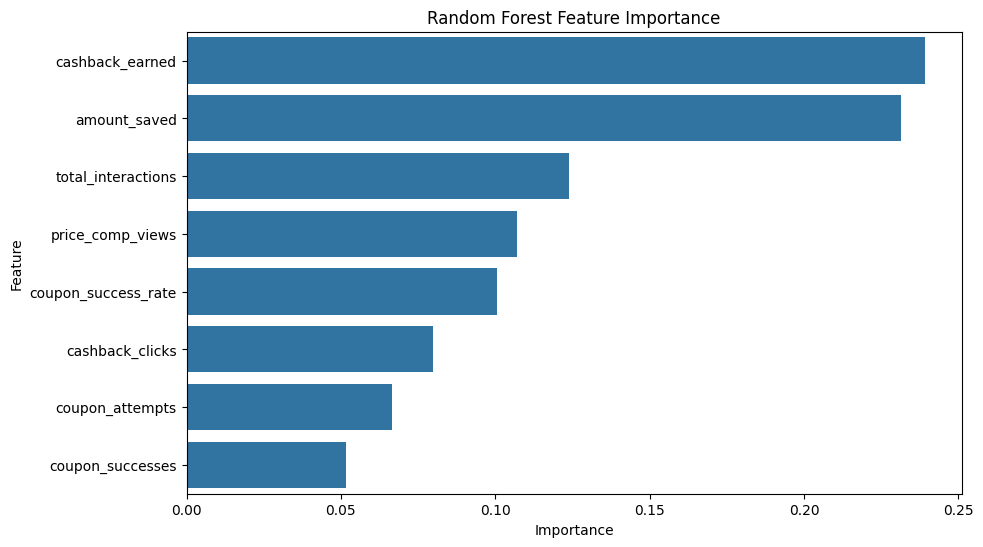

In [9]:
# Plot Feature Importances for Random Forest
feature_importances = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances)
plt.title('Random Forest Feature Importance')
plt.show()

**What & Why we did this**: 
We extracted and plotted the feature importances to interpret the Random Forest's "black box". In an industry setting (like a Shopping Extension), Product Managers care immensely about the 'Why'. If we know `cashback_earned` is the highest predictor of retention, stakeholders can prioritize engineering efforts to make cashback more prominent in the app UI.

**Interviewer Questions**:
- *"How does a Random Forest calculate feature importance natively?"*
  - **Answer**: Through Mean Impurity Decrease (often Gini Impurity). The algorithm tracks how much a specific feature successfully split the data and decreased the "impurity" (disorder) across all trees in the forest.
- *"Are there any known flaws with native Random Forest feature importance?"*
  - **Answer**: Yes, impurity-based feature importance is biased toward features with high cardinality (many unique continuous values) over categorical features. Permutation Importance or employing SHAP (SHapley Additive exPlanations) values offer far more robust, unbiased interpretability.